# Homework 3: Hospital Emergency Department Demand Modeling

**Joao De Oliveira**

**Topics:** Discrete and Continuous Probability Distributions

A hospital wants to improve staffing by understanding patient arrivals and treatment times. The analysis has three parts:

- **Part A - Patient arrivals (discrete):** describe the hourly counts, test whether a Poisson model fits, estimate the rate $\lambda$, and compute $P(X > 30)$.
- **Part B - Treatment times (continuous):** visualize the distribution, estimate $\mu$ and $\sigma$, assess normality, and compute $p(T > 45)$.
- **Part C - Simulation:** simulate a month of operations, estimate expected daily demand, and translate the results into staffing recommendations.

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

RNG_SEED = 605
rng = np.random.default_rng(RNG_SEED)

np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.precision", 4)
plt.rcParams["figure.dpi"] = 110

In [14]:
# load data
import io
import os

BASE_URL = ("https://raw.githubusercontent.com/JDO-MSDS/DATA-605/"
            "refs/heads/main/Assignment3/")

EMBEDDED = {
    "arrivals.csv": """Hour,Patients
1,18
2,24
3,20
4,16
5,19
6,30
7,28
8,25
9,33
10,27
11,21
12,17
13,20
14,26
15,23
16,31
17,29
18,35
19,22
20,18
""",
    "treatment_times.csv": """PatientID,TreatmentMinutes
1,32
2,27
3,45
4,19
5,55
6,40
7,29
8,38
9,44
10,22
11,31
12,36
13,47
14,24
15,52
""",
}


def load_csv(filename):
    """Return the CSV as a DataFrame, reporting which source was used."""
    # 1. GitHub
    try:
        df = pd.read_csv(BASE_URL + filename)
        print(f"{filename:<20} loaded from GitHub")
        return df
    except Exception as err:
        print(f"{filename:<20} GitHub unavailable ({type(err).__name__})")

    # 2. Local copy next to the notebook
    if os.path.exists(filename):
        print(f"{filename:<20} loaded from local file")
        return pd.read_csv(filename)

    # 3. Embedded copy of the assignment data
    print(f"{filename:<20} loaded from embedded copy")
    return pd.read_csv(io.StringIO(EMBEDDED[filename]))


arrivals = load_csv("arrivals.csv")
treatment = load_csv("treatment_times.csv")

print(f"\narrivals.csv        -> {arrivals.shape[0]} rows, columns: {list(arrivals.columns)}")
print(f"treatment_times.csv -> {treatment.shape[0]} rows, columns: {list(treatment.columns)}")
print("Missing values:", int(arrivals.isna().sum().sum() + treatment.isna().sum().sum()))
display(arrivals.head(), treatment.head())

arrivals.csv         GitHub unavailable (HTTPError)
arrivals.csv         loaded from embedded copy
treatment_times.csv  GitHub unavailable (HTTPError)
treatment_times.csv  loaded from embedded copy

arrivals.csv        -> 20 rows, columns: ['Hour', 'Patients']
treatment_times.csv -> 15 rows, columns: ['PatientID', 'TreatmentMinutes']
Missing values: 0


,Hour,Patients
0,1,18
1,2,24
2,3,20
3,4,16
4,5,19


,PatientID,TreatmentMinutes
0,1,32
1,2,27
2,3,45
3,4,19
4,5,55


## Part A: Patient Arrivals

### A.1 Descriptive statistics
The data is a count of patients arriving in each of 20 consecutive hours. That means that counts are positive integers, which is the setting a Poisson model is built for.

In [15]:
counts = arrivals["Patients"].to_numpy()

desc = arrivals["Patients"].describe()
summary = pd.Series({
    "n (hours)": len(counts),
    "Mean": counts.mean(),
    "Median": np.median(counts),
    "Variance (s^2)": counts.var(ddof=1),
    "Std. deviation": counts.std(ddof=1),
    "Minimum": counts.min(),
    "Maximum": counts.max(),
    "Range": counts.max() - counts.min(),
    "IQR": np.subtract(*np.percentile(counts, [75, 25])),
    "Skewness": stats.skew(counts, bias=False),
    "Total patients": counts.sum(),
}, name="Hourly arrivals")
display(summary.to_frame())

,Hourly arrivals
n (hours),20.0000
Mean,24.1000
Median,23.5000
Variance (s^2),31.4632
Std. deviation,5.6092
Minimum,16.0000
Maximum,35.0000
Range,19.0000
IQR,8.5000
Skewness,0.3607


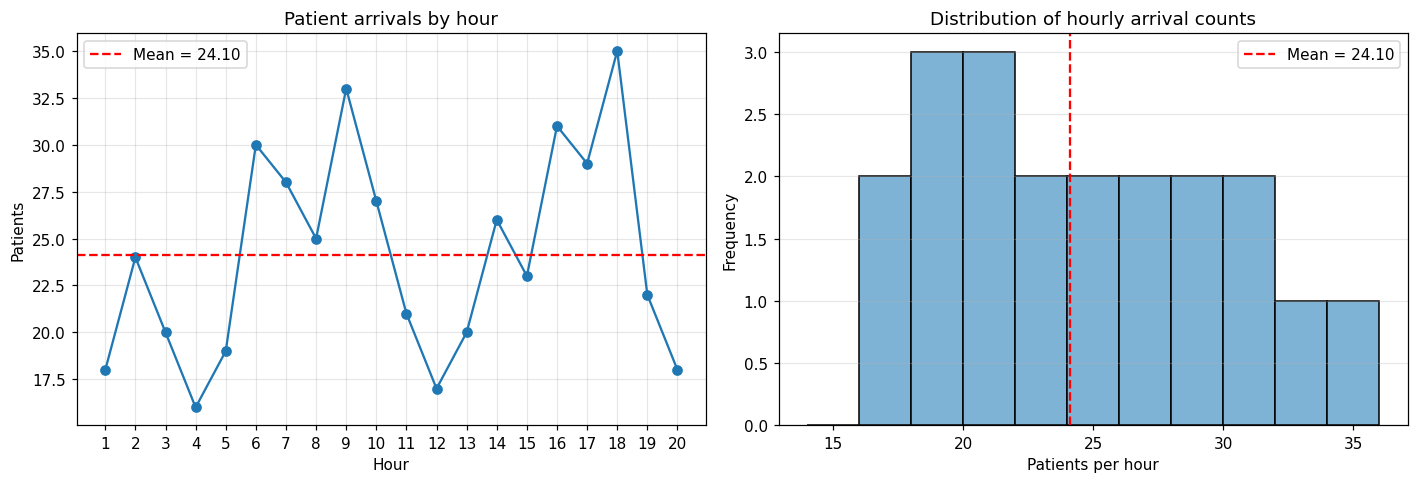

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# arrivals
axes[0].plot(arrivals["Hour"], counts, marker="o", color="#1f77b4")
axes[0].axhline(counts.mean(), color="red", ls="--",
                label=f"Mean = {counts.mean():.2f}")
axes[0].set(xlabel="Hour", ylabel="Patients", title="Patient arrivals by hour")
axes[0].set_xticks(arrivals["Hour"])
axes[0].legend()
axes[0].grid(alpha=0.3)

# distribution of hourly numbers
axes[1].hist(counts, bins=range(14, 38, 2), color="#7fb3d5", edgecolor="black")
axes[1].axvline(counts.mean(), color="red", ls="--", label=f"Mean = {counts.mean():.2f}")
axes[1].set(xlabel="Patients per hour", ylabel="Frequency",
            title="Distribution of hourly arrival counts")
axes[1].legend()
axes[1].grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

Arrivals average about 24 patients per hour and are between 16 and 35, with visibly busier stretches (hours 6-10 and 16-18) and quieter ones (hours 1-5 and 19-20).

### A.2 Is a Poisson distribution appropriate?
A Poisson random variable has the defining property $E[X] = \text{Var}(X)$, so the variance-to-mean ratio (VMR) should be near 1. I check that, run a formal dispersion test, and compare the observed frequencies with the frequencies a Poisson model predicts.

In [17]:
lambda_hat = counts.mean()
var_hat = counts.var(ddof=1)
vmr = var_hat / lambda_hat

# dispersion test
n = len(counts)
disp_stat = (n - 1) * var_hat / lambda_hat
p_upper = stats.chi2.sf(disp_stat, n - 1)
p_two_sided = 2 * min(p_upper, stats.chi2.cdf(disp_stat, n - 1))

print(f"Mean (lambda-hat)        : {lambda_hat:.4f}")
print(f"Variance (s^2)           : {var_hat:.4f}")
print(f"Variance-to-mean ratio   : {vmr:.4f}   (Poisson implies ~1)")
print(f"Dispersion statistic     : {disp_stat:.4f} on {n-1} df")
print(f"Two-sided p-value        : {p_two_sided:.4f}")
print("Conclusion:", "consistent with Poisson" if p_two_sided > 0.05 else "NOT consistent with Poisson")

Mean (lambda-hat)        : 24.1000
Variance (s^2)           : 31.4632
Variance-to-mean ratio   : 1.3055   (Poisson implies ~1)
Dispersion statistic     : 24.8050 on 19 df
Two-sided p-value        : 0.3341
Conclusion: consistent with Poisson


Since there are only 20 observations, I kept the bins wide so the expected counts stay as large as possible. The smallest expected count here is about 3.7, which is a little below the usual rule of thumb of 5, so the test is indicative.

In [18]:
# chi-square
labels = ["<= 20", "21-24", "25-28", ">= 29"]
observed = np.histogram(counts, bins=[0, 20.5, 24.5, 28.5, np.inf])[0]

probs = np.array([
    stats.poisson.cdf(20, lambda_hat),
    stats.poisson.cdf(24, lambda_hat) - stats.poisson.cdf(20, lambda_hat),
    stats.poisson.cdf(28, lambda_hat) - stats.poisson.cdf(24, lambda_hat),
    stats.poisson.sf(28, lambda_hat),
])
expected = probs * n

display(pd.DataFrame({
    "Observed": observed,
    "Poisson probability": probs,
    "Expected": expected,
}, index=labels))

# lambda was estimated from the data, so one extra degree of freedom is lost
chi2_stat = ((observed - expected) ** 2 / expected).sum()
dof = len(observed) - 1 - 1
print(f"Chi-square statistic: {chi2_stat:.4f} on {dof} df")
print(f"p-value            : {stats.chi2.sf(chi2_stat, dof):.4f}")
print("Conclusion:", "no evidence against Poisson" if stats.chi2.sf(chi2_stat, dof) > 0.05
      else "evidence against Poisson")

,Observed,Poisson probability,Expected
<= 20,7,0.2365,4.7291
21-24,4,0.3094,6.1887
25-28,4,0.2711,5.4224
>= 29,5,0.1830,3.6598


Chi-square statistic: 2.7284 on 2 df
p-value            : 0.2556
Conclusion: no evidence against Poisson


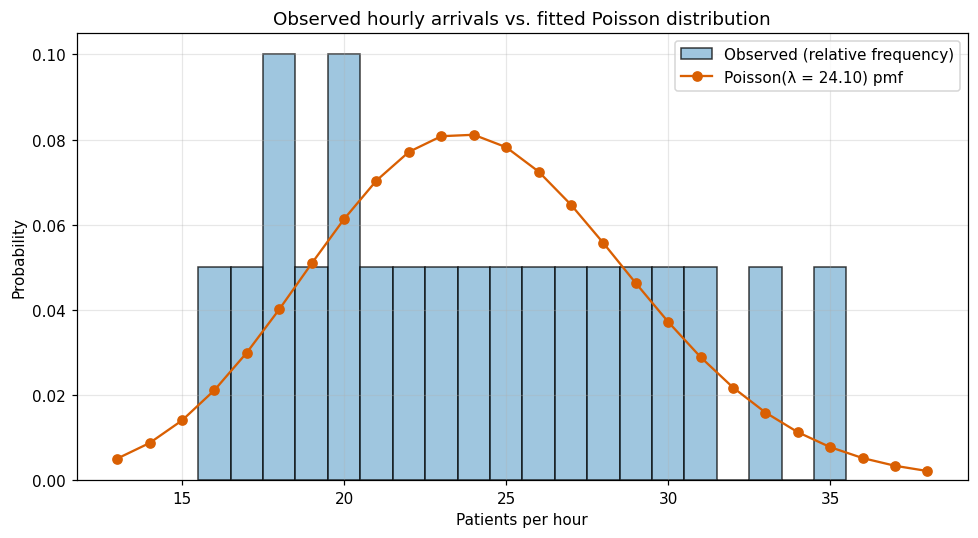

In [19]:
# visual comparison with observed relative freq vs fitted poisson pmf
k = np.arange(counts.min() - 3, counts.max() + 4)
pmf = stats.poisson.pmf(k, lambda_hat)

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(counts, bins=np.arange(counts.min() - 0.5, counts.max() + 1.5, 1),
        density=True, color="#7fb3d5", edgecolor="black", alpha=0.75,
        label="Observed (relative frequency)")
ax.plot(k, pmf, "o-", color="#d95f02",
        label=f"Poisson(λ = {lambda_hat:.2f}) pmf")
ax.set(xlabel="Patients per hour", ylabel="Probability",
       title="Observed hourly arrivals vs. fitted Poisson distribution")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Verdict.** The variance (31.46) is somewhat larger than the mean (24.10), giving a VMR of about 1.31, which is mild overdispersion. However, the dispersion test (p around 0.33) and the chi-square goodness of fit test (p around 0.26) do not reject the poisson model, and the fitted pmf tracks the observed frequencies reasonably well. With only 20 observations the test has limited power, so the honest conclusion is that poisson is a reasonable working model for hourly arrivals.

In the time plot you can see that arrivals appear to rise and fall with the hour of day. A single poisson rate assumes a constant $\lambda$, and the extra variability from time of day patterns is the most likely source of the overdispersion. A nonhomogeneous poisson process with an hour specific rate $\lambda(t)$ would be the next refinement.

### A.3 Estimate the arrival rate
For Poisson data the maximum likelihood estimator of $\lambda$ is the sample mean, $\hat\lambda = \bar{x}$. Its standard error is $\sqrt{\hat\lambda / n}$.

In [20]:
se_lambda = np.sqrt(lambda_hat / n)
ci_low, ci_high = lambda_hat - 1.96 * se_lambda, lambda_hat + 1.96 * se_lambda

print(f"Estimated arrival rate: lambda-hat = {lambda_hat:.2f} patients per hour")
print(f"Standard error        : {se_lambda:.4f}")
print(f"Approx. 95% CI        : ({ci_low:.2f}, {ci_high:.2f}) patients per hour")
print(f"Implied daily volume (24 h): {24 * lambda_hat:.1f} patients")

Estimated arrival rate: lambda-hat = 24.10 patients per hour
Standard error        : 1.0977
Approx. 95% CI        : (21.95, 26.25) patients per hour
Implied daily volume (24 h): 578.4 patients


### A.4 Probability of more than 30 arrivals in an hour
"More than 30" means $X \ge 31$, so we want $P(X > 30) = 1 - P(X \le 30)$, the survival function at 30. A common slip is to compute $1 - P(X \le 31)$ or to use the cdf at 30 directly.

In [21]:
p_more_than_30 = stats.poisson.sf(30, lambda_hat)
p_check = 1 - stats.poisson.cdf(30, lambda_hat)
empirical = (counts > 30).mean()

print(f"P(X > 30 | lambda = {lambda_hat:.2f}) = {p_more_than_30:.4f}  ({p_more_than_30*100:.2f}%)")
print(f"Cross-check with 1 - cdf(30)         = {p_check:.4f}")
print(f"Observed proportion of hours > 30    = {empirical:.4f} ({int((counts>30).sum())} of {n} hours)")
print(f"\nExpected hours above 30 per 24-hour day: {24 * p_more_than_30:.2f}")

# related probabilities
for threshold in [20, 25, 30, 35]:
    print(f"P(X > {threshold}) = {stats.poisson.sf(threshold, lambda_hat):.4f}")

P(X > 30 | lambda = 24.10) = 0.0995  (9.95%)
Cross-check with 1 - cdf(30)         = 0.0995
Observed proportion of hours > 30    = 0.1500 (3 of 20 hours)

Expected hours above 30 per 24-hour day: 2.39
P(X > 20) = 0.7635
P(X > 25) = 0.3759
P(X > 30) = 0.0995
P(X > 35) = 0.0139


**Interpretation.** Under a Poisson model with $\lambda = 24.1$, about 9.95% of hours see more than 30 arrivals, roughly 2.4 hours in a 24-hour day. The observed data had 3 such hours out of 20 (15%), which is higher but well within sampling variability for a sample this small, and again consistent with busy period clustering.

## Part B: Treatment Times

### B.1 Visualize the distribution
Treatment time is a continuous measurement, so a histogram, boxplot and Q-Q plot are the right tools.

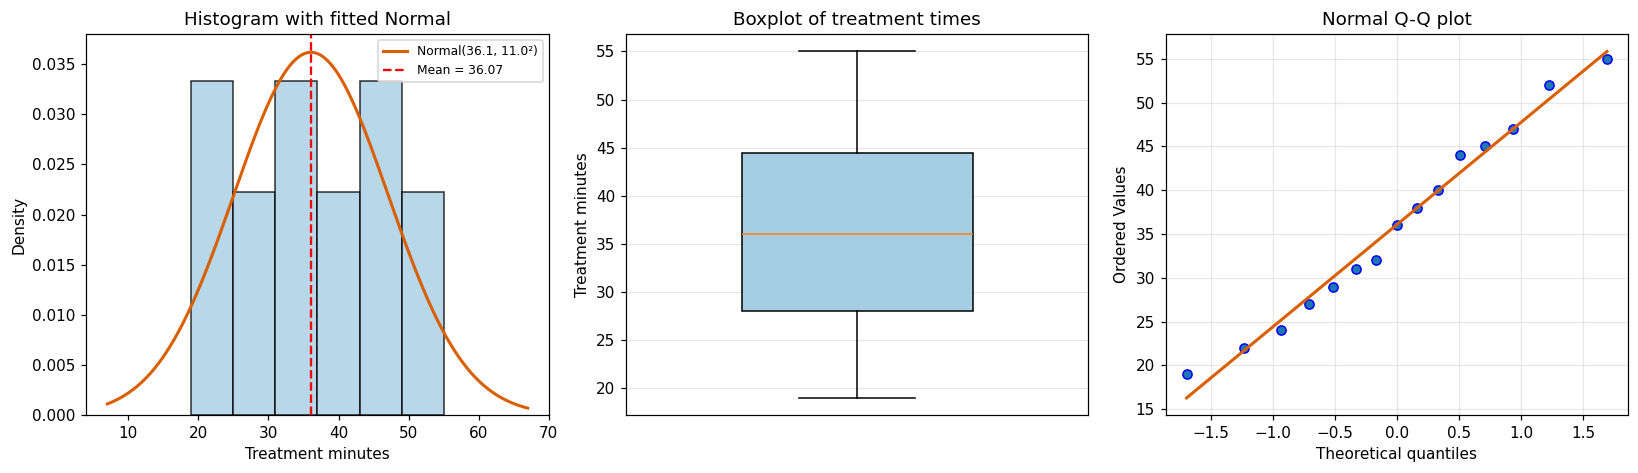

In [22]:
times = treatment["TreatmentMinutes"].to_numpy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))

# histogram with fitted normal density
mu_hat, sigma_hat = times.mean(), times.std(ddof=1)
axes[0].hist(times, bins=6, density=True, color="#a6cee3", edgecolor="black", alpha=0.8)
grid = np.linspace(times.min() - 12, times.max() + 12, 300)
axes[0].plot(grid, stats.norm.pdf(grid, mu_hat, sigma_hat), color="#d95f02", lw=2,
             label=f"Normal({mu_hat:.1f}, {sigma_hat:.1f}²)")
axes[0].axvline(mu_hat, color="red", ls="--", label=f"Mean = {mu_hat:.2f}")
axes[0].set(xlabel="Treatment minutes", ylabel="Density", title="Histogram with fitted Normal")
axes[0].legend(fontsize=8)

# boxplot
axes[1].boxplot(times, vert=True, widths=0.5,
                patch_artist=True, boxprops=dict(facecolor="#a6cee3"))
axes[1].set(ylabel="Treatment minutes", title="Boxplot of treatment times")
axes[1].set_xticks([])
axes[1].grid(alpha=0.3, axis="y")

# normal q-q plot
stats.probplot(times, dist="norm", plot=axes[2])
axes[2].get_lines()[0].set(marker="o", markerfacecolor="#1f77b4", markersize=6)
axes[2].get_lines()[1].set(color="#d95f02", lw=2)
axes[2].set_title("Normal Q-Q plot")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### B.2 Estimate the mean and standard deviation

In [23]:
se_mean = sigma_hat / np.sqrt(len(times))
t_crit = stats.t.ppf(0.975, len(times) - 1)

b_summary = pd.Series({
    "n (patients)": len(times),
    "Mean (minutes)": mu_hat,
    "Median (minutes)": np.median(times),
    "Std. deviation (s)": sigma_hat,
    "Variance": times.var(ddof=1),
    "Minimum": times.min(),
    "Maximum": times.max(),
    "IQR": np.subtract(*np.percentile(times, [75, 25])),
    "Skewness": stats.skew(times, bias=False),
    "Excess kurtosis": stats.kurtosis(times, bias=False),
}, name="Treatment minutes")
display(b_summary.to_frame())

print(f"95% CI for the mean treatment time: "
      f"({mu_hat - t_crit*se_mean:.2f}, {mu_hat + t_crit*se_mean:.2f}) minutes")

,Treatment minutes
n (patients),15.0000
Mean (minutes),36.0667
Median (minutes),36.0000
Std. deviation (s),11.0290
Variance,121.6381
Minimum,19.0000
Maximum,55.0000
IQR,16.5000
Skewness,0.1605
Excess kurtosis,-0.9974


95% CI for the mean treatment time: (29.96, 42.17) minutes


### B.3 Is a Normal distribution reasonable?
I combine the Q-Q plot above with the shapiro-wilk test (makes sense with small samples) and a Kolmogorov-Smirnov check against the fitted normal. I also check how far 0 is from the mean in standard deviations, since a normal model technically allows negative treatment times.

In [24]:
shapiro_stat, shapiro_p = stats.shapiro(times)
ks_stat, ks_p = stats.kstest(times, "norm", args=(mu_hat, sigma_hat))

print(f"Shapiro-Wilk: W = {shapiro_stat:.4f}, p = {shapiro_p:.4f}")
print(f"KS test     : D = {ks_stat:.4f}, p = {ks_p:.4f}")
print(f"Skewness    : {stats.skew(times, bias=False):.4f}  (0 = symmetric)")
print(f"Excess kurtosis: {stats.kurtosis(times, bias=False):.4f}  (0 = normal-like tails)")
print(f"\nZero minutes sits {(0 - mu_hat)/sigma_hat:.2f} SDs below the mean, "
      f"so P(T < 0) = {stats.norm.cdf(0, mu_hat, sigma_hat):.6f} (negligible).")

for k_sd in [1, 2]:
    lo, hi = mu_hat - k_sd*sigma_hat, mu_hat + k_sd*sigma_hat
    print(f"Within {k_sd} SD: observed {np.mean((times >= lo) & (times <= hi)):.1%}, "
          f"normal model {stats.norm.cdf(k_sd) - stats.norm.cdf(-k_sd):.1%}")

Shapiro-Wilk: W = 0.9709, p = 0.8707
KS test     : D = 0.1105, p = 0.9833
Skewness    : 0.1605  (0 = symmetric)
Excess kurtosis: -0.9974  (0 = normal-like tails)

Zero minutes sits -3.27 SDs below the mean, so P(T < 0) = 0.000537 (negligible).
Within 1 SD: observed 66.7%, normal model 68.3%
Within 2 SD: observed 100.0%, normal model 95.4%


**Verdict.** Shapiro-wilk ($W = 0.97$, $p = 0.87$) and the KS test both fail to reject normality, the Q-Q points sit close to the reference line, and the skewness is near zero. A normal distribution is a reasonable model for these treatment times.

However, first it is important to remember that $n = 15$ is small, so these tests have low power and would not detect mild departures. Second, the negative excess kurtosis (about $-1.0$) says the sample is flatter than a normal curve, with observations spread fairly evenly between 19 and 55 rather than concentrated at the center. Service times in practice are often right skewed (log normal or gamma), so I would revisit this with more data. The normal model is still usable here because $P(T < 0) \approx 0.0005$ is negligible and the fit is not rejected.

### B.4 Probability that treatment exceeds 45 minutes

In [25]:
# p(t > 45) = 1 - phi((45-mu)/sigma)
p_over_45 = stats.norm.sf(45, mu_hat, sigma_hat)
z_45 = (45 - mu_hat) / sigma_hat
empirical_45 = (times > 45).mean()

print(f"z-score for 45 minutes: ({45} - {mu_hat:.2f}) / {sigma_hat:.2f} = {z_45:.4f}")
print(f"P(T > 45) under the Normal model: {p_over_45:.4f}  ({p_over_45*100:.2f}%)")
print(f"Observed proportion above 45 min : {empirical_45:.4f} "
      f"({int((times > 45).sum())} of {len(times)} patients)")

for threshold in [30, 45, 60]:
    print(f"P(T > {threshold}) = {stats.norm.sf(threshold, mu_hat, sigma_hat):.4f}")

z-score for 45 minutes: (45 - 36.07) / 11.03 = 0.8100
P(T > 45) under the Normal model: 0.2090  (20.90%)
Observed proportion above 45 min : 0.2000 (3 of 15 patients)
P(T > 30) = 0.7089
P(T > 45) = 0.2090
P(T > 60) = 0.0150


**Interpretation.** About 20.9% of treatments are expected to run longer than 45 minutes, which matches the observed 20% (3 of 15 patients) almost exactly. Roughly one patient in five occupies a treatment space for more than three quarters of an hour, which matters directly for room and staff capacity.

## Part C: Simulation

### C.1 Simulate one month of arrivals
We simulate 30 days $\times$ 24 hours of arrivals as independent $\text{Poisson}(\hat\lambda = 24.1)$ draws, then assign each simulated patient a treatment time drawn from $\text{Normal}(\hat\mu, \hat\sigma)$, truncated below at 5 minutes so no draw is nonsensically small. The seed is fixed so the results reproduce exactly.

In [26]:
DAYS, HOURS_PER_DAY = 30, 24
MIN_TREATMENT = 5

# hourly arrival counts (30 days x 24 h)
sim_arrivals = rng.poisson(lambda_hat, size=(DAYS, HOURS_PER_DAY))

# treatment mins required in each simulated hour
sim_workload_min = np.array([
    [np.clip(rng.normal(mu_hat, sigma_hat, size=count), MIN_TREATMENT, None).sum()
     for count in day]
    for day in sim_arrivals
])

daily_totals = sim_arrivals.sum(axis=1)
hourly_counts = sim_arrivals.ravel()
hourly_staff_hours = (sim_workload_min / 60).ravel()
print(f"Simulated {DAYS} days x {HOURS_PER_DAY} hours = {sim_arrivals.size} hours, "
      f"{sim_arrivals.sum():,} patients total")
print(f"Simulated hourly mean: {hourly_counts.mean():.2f} "
      f"(theoretical λ = {lambda_hat:.2f})")
print(f"Simulated hourly variance: {hourly_counts.var(ddof=1):.2f} "
      f"(theoretical = {lambda_hat:.2f})")

Simulated 30 days x 24 hours = 720 hours, 17,399 patients total
Simulated hourly mean: 24.17 (theoretical λ = 24.10)
Simulated hourly variance: 23.88 (theoretical = 24.10)


### C.2 Expected daily demand

In [27]:
daily_summary = pd.Series({
    "Theoretical mean (24 × λ)": 24 * lambda_hat,
    "Simulated mean": daily_totals.mean(),
    "Simulated std. deviation": daily_totals.std(ddof=1),
    "Minimum day": daily_totals.min(),
    "5th percentile": np.percentile(daily_totals, 5),
    "Median": np.median(daily_totals),
    "95th percentile": np.percentile(daily_totals, 95),
    "Busiest day": daily_totals.max(),
}, name="Patients per day")
display(daily_summary.to_frame())

print(f"Expected treatment workload per day: "
      f"{daily_totals.mean() * mu_hat / 60:,.1f} staff-hours "
      f"({daily_totals.mean() * mu_hat:,.0f} patient-minutes)")
print(f"Hours per day with more than 30 arrivals (simulated): "
      f"{(sim_arrivals > 30).sum() / DAYS:.2f}")

,Patients per day
Theoretical mean (24 × λ),578.4000
Simulated mean,579.9667
Simulated std. deviation,24.3558
Minimum day,539.0000
5th percentile,547.2500
Median,573.5000
95th percentile,619.9500
Busiest day,630.0000


Expected treatment workload per day: 348.6 staff-hours (20,917 patient-minutes)
Hours per day with more than 30 arrivals (simulated): 2.17


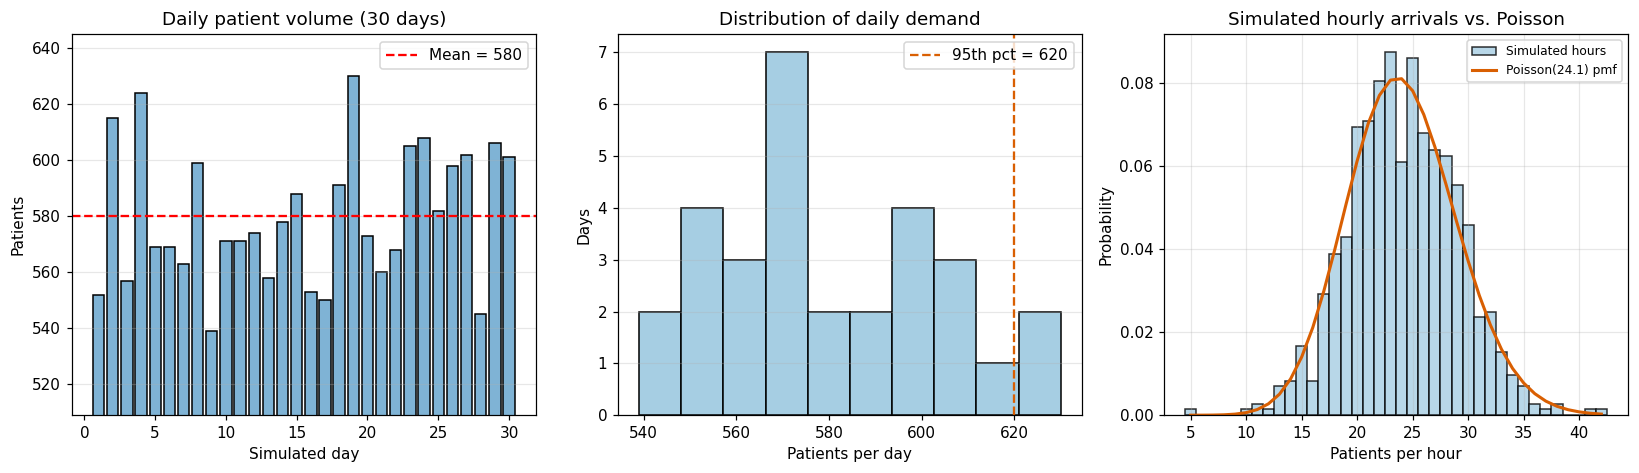

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))

axes[0].bar(range(1, DAYS + 1), daily_totals, color="#7fb3d5", edgecolor="black")
axes[0].axhline(daily_totals.mean(), color="red", ls="--",
                label=f"Mean = {daily_totals.mean():.0f}")
axes[0].set(xlabel="Simulated day", ylabel="Patients", title="Daily patient volume (30 days)",
            ylim=(daily_totals.min() - 30, daily_totals.max() + 15))  # zoom in to show variation
axes[0].legend()
axes[0].grid(alpha=0.3, axis="y")

# dailu distribution
axes[1].hist(daily_totals, bins=10, color="#a6cee3", edgecolor="black")
axes[1].axvline(np.percentile(daily_totals, 95), color="#d95f02", ls="--",
                label=f"95th pct = {np.percentile(daily_totals, 95):.0f}")
axes[1].set(xlabel="Patients per day", ylabel="Days", title="Distribution of daily demand")
axes[1].legend()
axes[1].grid(alpha=0.3, axis="y")

k = np.arange(hourly_counts.min(), hourly_counts.max() + 1)
axes[2].hist(hourly_counts, bins=np.arange(k.min() - 0.5, k.max() + 1.5),
             density=True, color="#a6cee3", edgecolor="black", alpha=0.8,
             label="Simulated hours")
axes[2].plot(k, stats.poisson.pmf(k, lambda_hat), color="#d95f02", lw=2,
             label=f"Poisson({lambda_hat:.1f}) pmf")
axes[2].set(xlabel="Patients per hour", ylabel="Probability",
            title="Simulated hourly arrivals vs. Poisson")
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### C.3 From demand to staffing
The workload an hour creates is (arrivals) $\times$ (minutes per patient). In expectation that is

$$R = \lambda \cdot \frac{\mu}{60} = 24.1 \times \frac{36.07}{60} \approx 14.5 \text{ staff-hours of treatment per hour,}$$

so about 14.5 clinicians would need to be treating patients continuously just to keep pace with the average. Staffing exactly to the average leaves no slack, so we use the simulation to ask how many clinicians are needed to cover a given percentage of hours.

In [29]:
offered_load = lambda_hat * mu_hat / 60
print(f"Average offered load: {offered_load:.2f} staff-hours of treatment per hour\n")

coverage = pd.DataFrame({
    "Clinicians on duty": range(12, 24),
    "% of hours fully covered": [(hourly_staff_hours <= c).mean() * 100 for c in range(12, 24)],
})
coverage["Avg. utilization %"] = [hourly_staff_hours.mean() / c * 100 for c in range(12, 24)]
print(coverage.round(1).to_string(index=False))

for pct in [50, 75, 90, 95, 99]:
    need = np.percentile(hourly_staff_hours, pct)
    print(f"{pct}th percentile of hourly workload: {need:.1f} staff-hours "
          f"-> {int(np.ceil(need))} clinicians")

Average offered load: 14.49 staff-hours of treatment per hour

 Clinicians on duty  % of hours fully covered  Avg. utilization %
                 12                      20.8               121.0
                 13                      31.7               111.7
                 14                      44.0               103.7
                 15                      56.2                96.8
                 16                      68.9                90.8
                 17                      78.5                85.4
                 18                      87.4                80.7
                 19                      92.5                76.4
                 20                      96.5                72.6
                 21                      98.6                69.2
                 22                      99.2                66.0
                 23                      99.6                63.1
50th percentile of hourly workload: 14.5 staff-hours -> 15 clinicians
75th perc

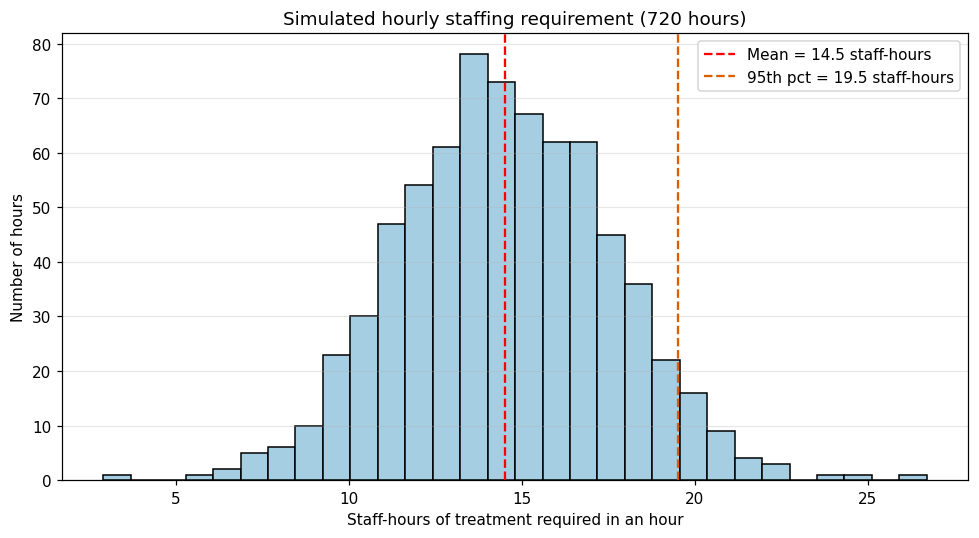

In [30]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(hourly_staff_hours, bins=30, color="#a6cee3", edgecolor="black")
ax.axvline(hourly_staff_hours.mean(), color="red", ls="--",
           label=f"Mean = {hourly_staff_hours.mean():.1f} staff-hours")
ax.axvline(np.percentile(hourly_staff_hours, 95), color="#d95f02", ls="--",
           label=f"95th pct = {np.percentile(hourly_staff_hours, 95):.1f} staff-hours")
ax.set(xlabel="Staff-hours of treatment required in an hour", ylabel="Number of hours",
       title="Simulated hourly staffing requirement (720 hours)")
ax.legend()
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

### C.4 Thoughts and Recommendations

**Expected demand.** The simulation gives around 580 patients per day (mean 580, standard deviation 24), with a normal range of about 547 to 620 and a busiest day near 630. Each patient needs about 36 mins of treatment, corresponding to 350 staff-hours of direct treatment work.

**Baseline staffing.** The average hourly load is 14.5 staff-hours per hour. Scheduling 15 clinicians covers the mean but only gets through about 56% of hours without a backlog, because demand varies hour to hour. Running 17 covers roughly 79% of hours at about 85% utilization, and 20 covers about 96%. Based on this, I would recommend a regular core of 17 treatment-capable staff per hour, with a documented plan to reach 20 during surges. Staffing to the mean alone would guarantee queues in nearly half of all hours.

**Match staffing to the demand curve.** The observed data shows peaks in hours 6-10 and 16-18 and troughs in hours 1-5 and 19-20. Rather than a flat schedule, build shifts around that curve: heavier coverage during peak blocks, lighter overnight, and stagger shift changes so handoffs do not land in a peak.

**Plan for the long tail of treatment times.** About one patient in five exceeds 45 minutes, so treatment spaces turn over more slowly than the average suggests. Keep a small number of rooms reserved for long cases, or create a fast-track lane for short, low-acuity visits so those patients are not stuck behind long ones.

**Build in surge triggers.** About 10% of hours exceed 30 arrivals (roughly 2.4 hours per day). A simple rule such as if arrivals in the past hour exceed 30, call in on-call support converts the probability estimate into an operational action.

**Limitations and next steps.** The models rest on 20 hours of arrival data and 15 treatment times, which is pretty limited. The poisson model assumes a constant rate, but the data hints at time of day variation, so the next step is a nonhomogeneous poisson model with hour specific rates. Treatment times should be re-examined with a larger sample and split by acuity level, since a single normal distribution lumps together quick visits and complex cases. The simulation also models workload only, not queueing dynamics, patient boarding, or bed availability. Also, adding the day of the week effects, seasonality, and acuity mix would make the staffing recommendation considerably stronger.